# EDA Gold — Table ML finale
## Analyse du lien entre pollen, météo et ruptures R06A (2021-2026)
**Notebook J4 — Collègue 2**

Sections :
1. Chargement et aperçu de la table Gold
2. Évolution graminées vs ruptures R06
3. Heatmap ruptures par mois × année
4. Matrice de corrélation
5. Boxplot graminées par classe de rupture
6. KPIs

## 1. Chargement et aperçu

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Remonter à la racine du projet depuis notebooks/
os.chdir('..')

sns.set_theme(style='whitegrid', palette='muted')

# Chargement de la table Gold
df = pd.read_csv('data/gold/gold_ml.csv')
df['annee_mois_dt'] = pd.to_datetime(df['annee_mois_str'])
df = df.sort_values('annee_mois_dt').reset_index(drop=True)

print(f'Shape : {df.shape}')
print(f'Période : {df["annee_mois_str"].min()} → {df["annee_mois_str"].max()}')
print(f'\nColonnes : {df.columns.tolist()}')
print(f'\nAperçu stats :')
print(df[['gram_moy','temp_moy','precip','nb_ruptures','target_rupture']].describe().round(2))

Shape : (60, 26)
Période : 2021-01 → 2026-06

Colonnes : ['annee_mois_str', 'gram_moy', 'gram_max', 'gram_roll7', 'gram_roll30', 'nb_jours_pic', 'bouleau_moy', 'ambroisie_moy', 'nb_jours_pic_bouleau', 'nb_jours_pic_ambroisie', 'temp_moy', 'temp_max', 'temp_min', 'temp_roll30', 'precip', 'precip_lag7', 'wind', 'mois', 'annee', 'saison_allergies', 'source_encoded', 'nb_ruptures', 'nb_risques', 'target_rupture', 'boites_total', 'annee_mois_dt']

Aperçu stats :
       gram_moy  temp_moy  precip  nb_ruptures  target_rupture
count     60.00     59.00   59.00         60.0           60.00
mean       8.73     12.75    2.40          0.2            0.38
std       17.33      5.88    0.93          0.4            0.49
min        0.00      3.84    0.33          0.0            0.00
25%        0.10      7.39    1.84          0.0            0.00
50%        1.18     12.72    2.31          0.0            0.00
75%        8.78     18.21    2.92          0.0            1.00
max       83.75     22.57    4.69 

## 2. Évolution graminées vs ruptures R06
> Ce graphique montre si les pics de pollen coïncident avec les ruptures de stock.
> L'axe gauche (vert) = concentration en graminées. L'axe droit (rouge) = rupture ou pas ce mois-là.

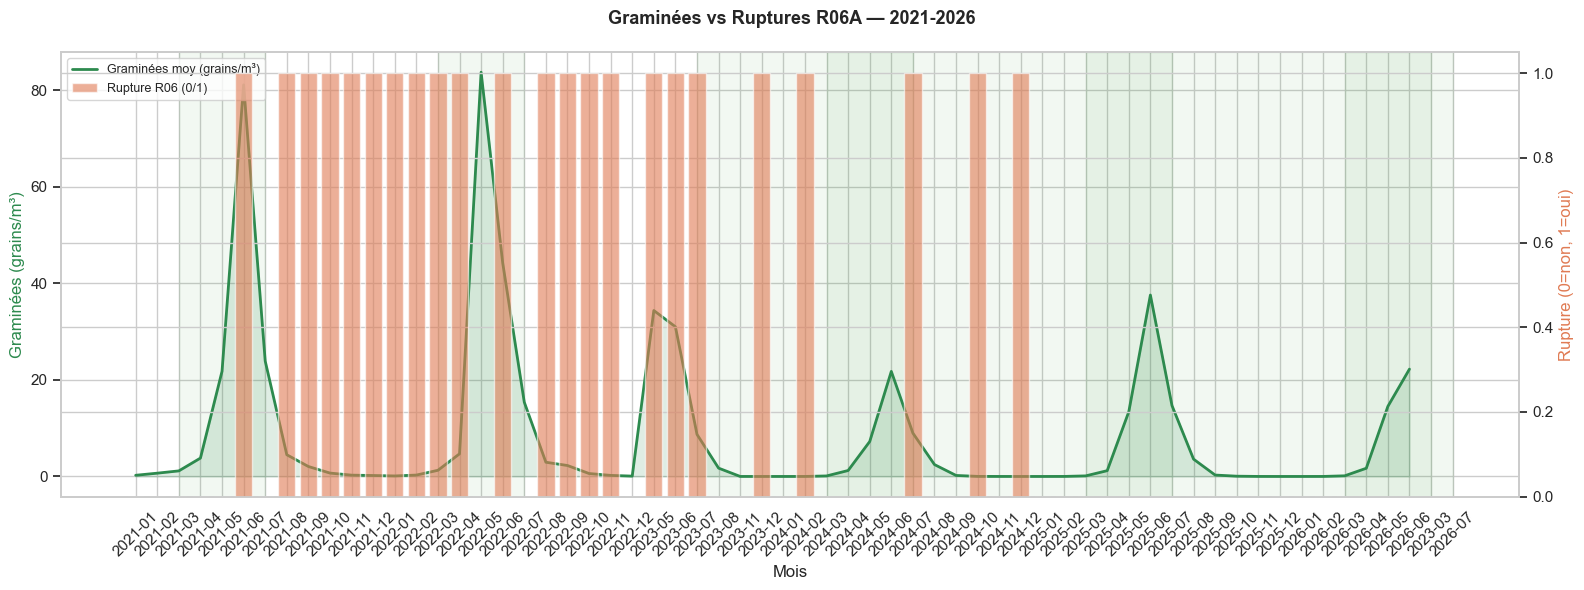

In [2]:
fig, ax1 = plt.subplots(figsize=(16, 6))
fig.suptitle('Graminées vs Ruptures R06A — 2021-2026', fontsize=13, fontweight='bold')

ax2 = ax1.twinx()

# Courbe pollen
ax1.plot(df['annee_mois_str'], df['gram_moy'],
         color='#2d8a4e', linewidth=2, label='Graminées moy (grains/m³)', zorder=3)
ax1.fill_between(df['annee_mois_str'], df['gram_moy'],
                 alpha=0.15, color='#2d8a4e')

# Barres ruptures
ax2.bar(df['annee_mois_str'], df['target_rupture'],
        color='#e07b54', alpha=0.6, label='Rupture R06 (0/1)', zorder=2)

ax1.set_xlabel('Mois')
ax1.set_ylabel('Graminées (grains/m³)', color='#2d8a4e')
ax2.set_ylabel('Rupture (0=non, 1=oui)', color='#e07b54')
ax1.tick_params(axis='x', rotation=45)

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

# Highlight saisons allergiques
for annee in df['annee'].unique():
    ax1.axvspan(f'{annee}-03', f'{annee}-07',
                alpha=0.05, color='green')

plt.tight_layout()
plt.savefig('notebooks/gold_graminees_ruptures.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Heatmap ruptures par mois × année
> Permet de voir si certains mois sont systématiquement plus à risque d'une année à l'autre.

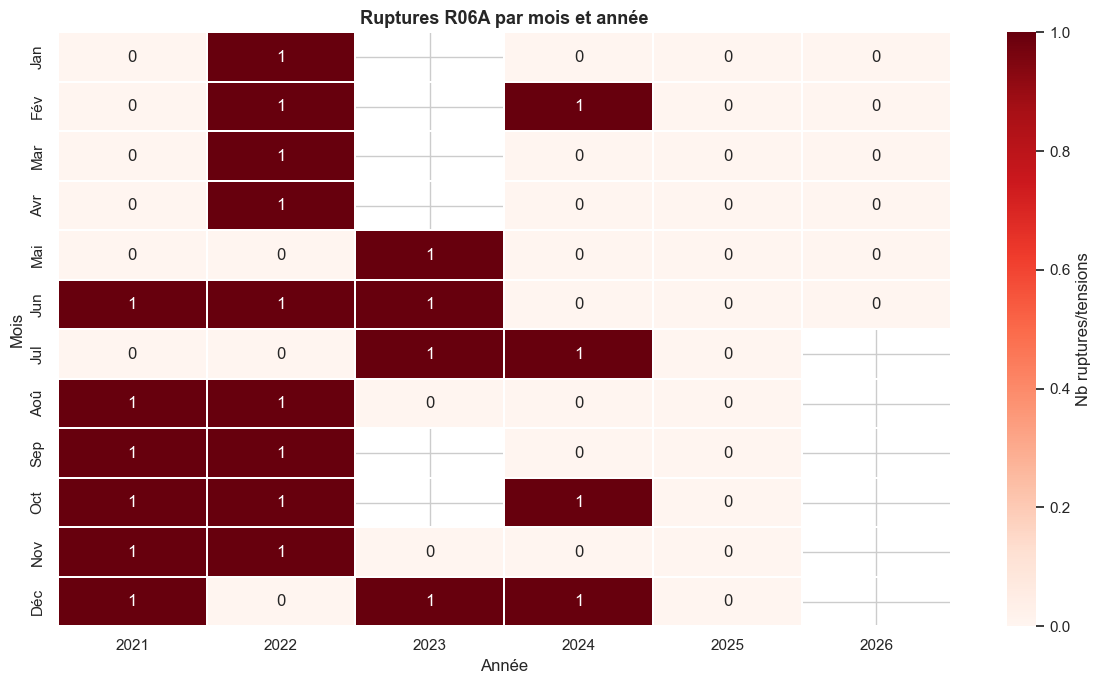

In [3]:
pivot = df.pivot_table(values='target_rupture',
                      index='mois', columns='annee', aggfunc='sum')

mois_labels = {1:'Jan',2:'Fév',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
               7:'Jul',8:'Aoû',9:'Sep',10:'Oct',11:'Nov',12:'Déc'}
pivot.index = [mois_labels.get(m, m) for m in pivot.index]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Nb ruptures/tensions'})
ax.set_title('Ruptures R06A par mois et année', fontsize=13, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Mois')
plt.tight_layout()
plt.savefig('notebooks/gold_heatmap_ruptures.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Matrice de corrélation
> Mesure le lien linéaire entre chaque variable. Une corrélation forte entre graminées et rupture
> confirme que le pollen est un bon prédicteur.

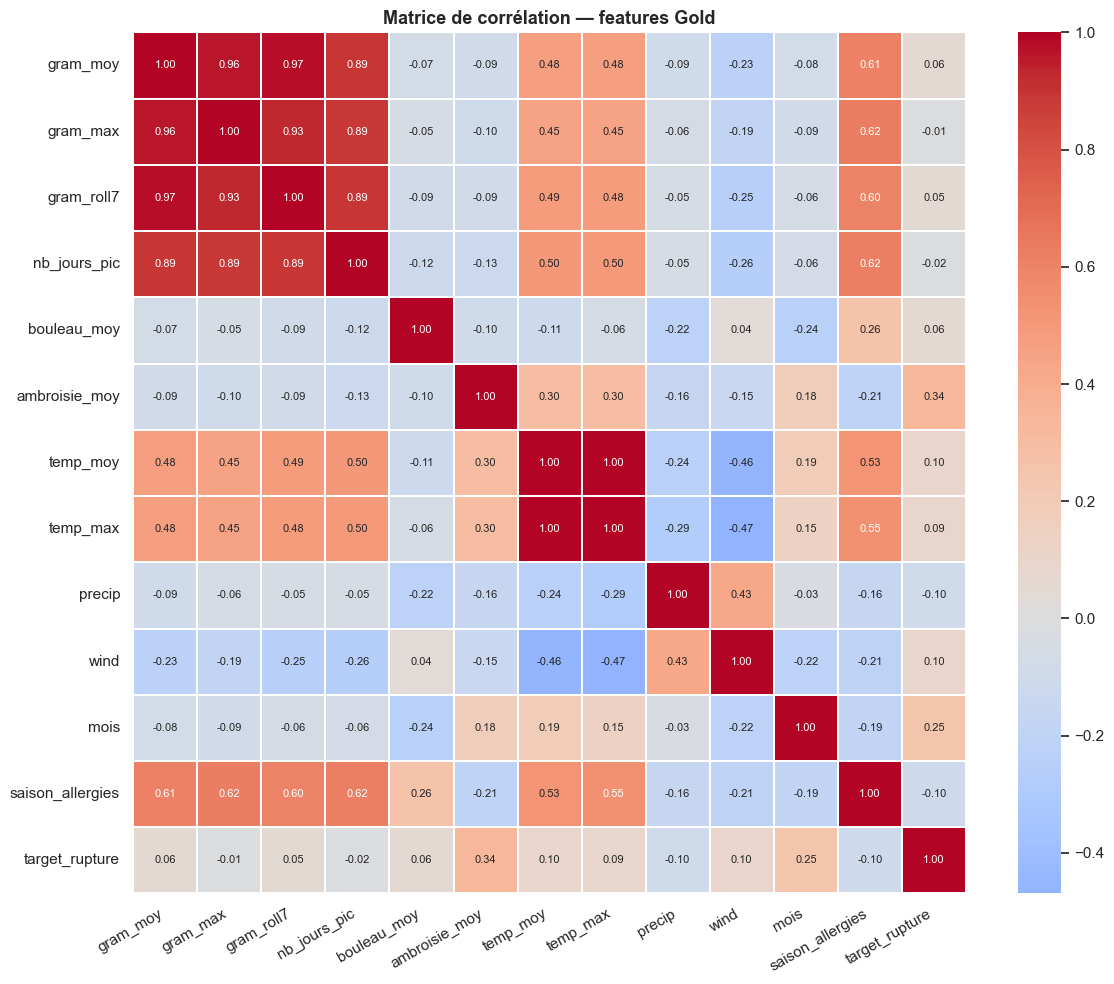


Corrélations avec target_rupture :
  ambroisie_moy                  : +0.343
  mois                           : +0.247
  temp_moy                       : +0.104
  wind                           : +0.096
  temp_max                       : +0.091
  bouleau_moy                    : +0.057
  gram_moy                       : +0.056
  gram_roll7                     : +0.052
  gram_max                       : -0.012
  nb_jours_pic                   : -0.016
  precip                         : -0.102
  saison_allergies               : -0.102


In [4]:
features_num = ['gram_moy','gram_max','gram_roll7','nb_jours_pic',
                'bouleau_moy','ambroisie_moy',
                'temp_moy','temp_max','precip','wind',
                'mois','saison_allergies','target_rupture']

# Garder uniquement les colonnes disponibles
features_num = [f for f in features_num if f in df.columns]
corr = df[features_num].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.3,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation — features Gold', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('notebooks/gold_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Corrélations avec target_rupture triées
print('\nCorrélations avec target_rupture :')
corr_target = corr['target_rupture'].drop('target_rupture').sort_values(ascending=False)
for feat, val in corr_target.items():
    print(f'  {feat:30s} : {val:+.3f}')

## 5. Boxplot graminées par classe de rupture
> Compare la distribution des concentrations polliniques selon qu'il y ait eu une rupture ou non.
> Si les boîtes sont bien séparées, le pollen est discriminant pour le ML.

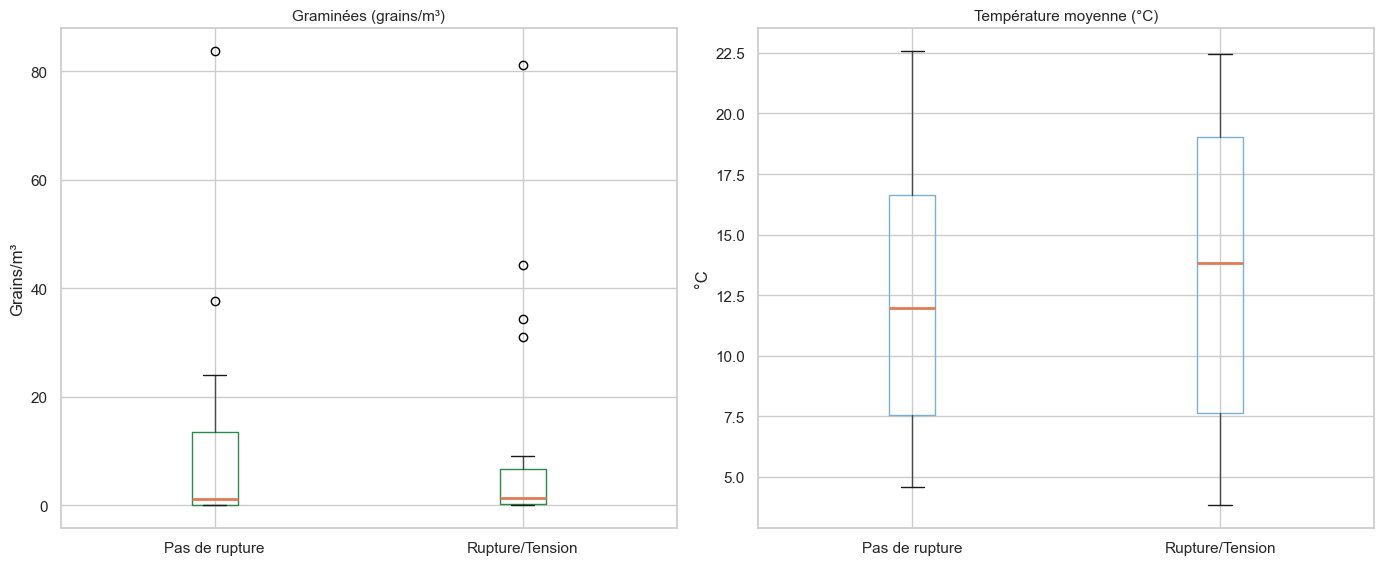

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution du pollen selon présence de rupture R06A',
             fontsize=13, fontweight='bold')

# Boxplot graminées
df_box = df.copy()
df_box['Rupture'] = df_box['target_rupture'].map({0: 'Pas de rupture', 1: 'Rupture/Tension'})

df_box.boxplot(column='gram_moy', by='Rupture', ax=axes[0],
               boxprops=dict(color='#2d8a4e'),
               medianprops=dict(color='#e07b54', linewidth=2))
axes[0].set_title('Graminées (grains/m³)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Grains/m³')
plt.sca(axes[0])
plt.suptitle('')

# Boxplot température
df_box.boxplot(column='temp_moy', by='Rupture', ax=axes[1],
               boxprops=dict(color='#7bafd4'),
               medianprops=dict(color='#e07b54', linewidth=2))
axes[1].set_title('Température moyenne (°C)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('°C')
plt.sca(axes[1])
plt.suptitle('')

plt.tight_layout()
plt.savefig('notebooks/gold_boxplot_graminees.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. KPIs — Insights clés
> Les chiffres clés à retenir pour la soutenance.

In [6]:
print('=' * 55)
print('KPIs TABLE GOLD — ANTIHISTAMINIQUES R06A')
print('=' * 55)

# Taux de rupture global
taux = df['target_rupture'].mean() * 100
print(f'\n  Taux de rupture/tension global : {taux:.1f}% des mois')
print(f'  Mois avec rupture : {df["target_rupture"].sum()} / {len(df)}')

# Mois le plus à risque
mois_risque = df.groupby('mois')['target_rupture'].mean().idxmax()
mois_labels = {1:'Janvier',2:'Février',3:'Mars',4:'Avril',5:'Mai',6:'Juin',
               7:'Juillet',8:'Août',9:'Septembre',10:'Octobre',11:'Novembre',12:'Décembre'}
print(f'\n  Mois le plus à risque : {mois_labels[mois_risque]} (mois {mois_risque})')

# Graminées moyennes selon rupture
seuil = df.groupby('target_rupture')['gram_moy'].mean()
print(f'\n  Graminées moy SANS rupture : {seuil[0]:.1f} grains/m³')
print(f'  Graminées moy AVEC rupture : {seuil[1]:.1f} grains/m³')
ratio = seuil[1] / seuil[0]
print(f'  → Ratio : {ratio:.1f}x plus de pollen pendant les ruptures')

# Corrélation pollen / rupture
corr_gr = df['gram_moy'].corr(df['target_rupture'])
corr_temp = df['temp_moy'].corr(df['target_rupture'])
corr_saison = df['saison_allergies'].corr(df['target_rupture'])
print(f'\n  Corrélation graminées/rupture   : {corr_gr:+.3f}')
print(f'  Corrélation température/rupture : {corr_temp:+.3f}')
print(f'  Corrélation saison/rupture      : {corr_saison:+.3f}')

# Taux par saison
taux_saison = df.groupby('saison_allergies')['target_rupture'].mean() * 100
print(f'\n  Taux rupture hors saison allergique : {taux_saison[0]:.1f}%')
print(f'  Taux rupture EN saison allergique   : {taux_saison[1]:.1f}%')

print(f'\n  MÉTRIQUES MODÈLES ML (baseline Collègue 3)')
print(f'  RF Regressor  R²      : 0.513')
print(f'  RF Classifier ROC-AUC : 0.743')
print('=' * 55)

KPIs TABLE GOLD — ANTIHISTAMINIQUES R06A

  Taux de rupture/tension global : 38.3% des mois
  Mois avec rupture : 23 / 60

  Mois le plus à risque : Octobre (mois 10)

  Graminées moy SANS rupture : 8.0 grains/m³
  Graminées moy AVEC rupture : 9.9 grains/m³
  → Ratio : 1.2x plus de pollen pendant les ruptures

  Corrélation graminées/rupture   : +0.056
  Corrélation température/rupture : +0.104
  Corrélation saison/rupture      : -0.102

  Taux rupture hors saison allergique : 42.1%
  Taux rupture EN saison allergique   : 31.8%

  MÉTRIQUES MODÈLES ML (baseline Collègue 3)
  RF Regressor  R²      : 0.513
  RF Classifier ROC-AUC : 0.743
